# Impulse Response Functions, FEVD & Granger Causality (Issue #48)
**DAMO-699 Capstone Project, Group 5**

## 1. Introduction & Motivation

`proposal/sections/05_analytical_approach.md` Section 5.3 commits the project to Impulse Response
Functions (IRF), Forecast Error Variance Decomposition (FEVD), and Granger causality tests on the
multivariate model. None of these had a `TIMELINE.md` task line until this issue surfaced the gap
(`SPRINT_AUG21_RECOVERY.md` §2).

This notebook runs all three on the **converged primary VECM from issue #47**: the 6-variable
system (`yield_spread_10y_2y`, `overnight_rate`, `us_treasury_10y`, `fed_funds_rate`, `cpi_yoy`,
`usdcad`), restricted-constant deterministic specification, cointegrating rank selected by the 95%
trace test. This is the same system issue #50's cross-model Diebold-Mariano scoring treats as
primary, so IRF/FEVD/Granger causality here describe the same model whose forecast accuracy is
reported elsewhere.

**Dependency:** #47 (Johansen cointegration test + conditional VECM) — CLOSED.

In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=Warning, module="statsmodels")

# Add project root to path
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from src.irf_fevd_granger import (
    fit_primary_vecm, compute_irf, one_sd_shock_response, summarize_irf_plain_language,
    compute_fevd, summarize_fevd_plain_language,
    run_granger_causality,
    BOND_YIELDS, POLICY_AND_FX_DRIVERS, IRF_SHOCK_VAR, IRF_PERIODS, SIGNIF,
)
from src.johansen_vecm import HORIZONS

print(f"Shock variable: {IRF_SHOCK_VAR}")
print(f"IRF/FEVD horizon: {IRF_PERIODS} trading days")
print(f"Bond yields (FEVD, Granger 'caused'): {BOND_YIELDS}")
print(f"Policy rate / exchange rate drivers (Granger 'causing'): {POLICY_AND_FX_DRIVERS}")

Shock variable: overnight_rate
IRF/FEVD horizon: 20 trading days
Bond yields (FEVD, Granger 'caused'): ['yield_spread_10y_2y', 'us_treasury_10y']
Policy rate / exchange rate drivers (Granger 'causing'): ['overnight_rate', 'fed_funds_rate', 'usdcad']


## 2. Refit the Primary VECM

> **Decision Justification:** IRF/FEVD/Granger causality all condition on a fitted VECM. Rather
> than hardcoding issue #47's `k_ar_diff=10` / `coint_rank=1` as disconnected magic numbers, this
> refits the model from the same load → ADF → lag-selection → Johansen steps `run_pipeline()`
> (`src/johansen_vecm.py`) uses, so a change in the upstream Gold-layer data would surface here
> instead of silently going stale. If the refit ever finds `r=0`, `fit_primary_vecm()` raises
> rather than proceeding on a model that no longer matches #47's merged result.

In [2]:
fit = fit_primary_vecm()
levels, vecm_fit = fit["levels"], fit["vecm_fit"]
print(f"\nk_ar_diff={fit['k_ar_diff']}, coint_rank={fit['coint_rank']}")
print(f"Variable order (Cholesky ordering for IRF/FEVD below): {list(levels.columns)}")

  6/6 series confirmed I(1).
    yield_spread_10y_2y        p_level=0.2525  p_diff=0.0000  [I(1)]
    overnight_rate             p_level=0.6268  p_diff=0.0000  [I(1)]
    us_treasury_10y            p_level=0.6474  p_diff=0.0000  [I(1)]
    fed_funds_rate             p_level=0.7988  p_diff=0.0000  [I(1)]
    cpi_yoy                    p_level=0.2365  p_diff=0.0000  [I(1)]
    usdcad                     p_level=0.6789  p_diff=0.0000  [I(1)]


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -8.899      -8.890   0.0001365      -8.896
1       -41.80     -41.74*   6.991e-19     -41.78*
2       -41.81      -41.69   6.971e-19      -41.77
3       -41.80      -41.63   6.992e-19      -41.74
4       -41.81      -41.58   6.979e-19      -41.73
5       -41.81      -41.53   6.967e-19      -41.71
6       -41.82      -41.49   6.863e-19      -41.71
7       -41.81      -41.43   6.923e-19      -41.68
8       -41.81      -41.37   6.958e-19      -41.65
9       -41.81      -41.31   6.976e-19      -41.63
10      -41.80      -41.25   7.027e-19      -41.61
11     -41.93*      -41.33  6.148e-19*      -41.72
12      -41.93      -41.28   6.163e-19      -41.70
13      -41.92      -41.22   6.198e-19      -41.67
14      -41.92      -41.15   6.248e-19      -41.65
15      -41.91      -41.09   6.286e-19      -41.62
-------------------------------

Det. terms outside the coint. relation & lagged endog. parameters for equation yield_spread_10y_2y
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
L1.yield_spread_10y_2y     -0.0483      0.017     -2.820      0.005      -0.082      -0.015
L1.overnight_rate           0.0019      0.013      0.143      0.886      -0.024       0.027
L1.us_treasury_10y          0.0141      0.009      1.488      0.137      -0.004       0.033
L1.fed_funds_rate           0.0058      0.012      0.487      0.626      -0.018       0.029
L1.cpi_yoy                  0.0049      0.005      0.987      0.323      -0.005       0.015
L1.usdcad                   0.0774      0.083      0.937      0.349      -0.084       0.239
L2.yield_spread_10y_2y      0.0018      0.017      0.106      0.915      -0.032       0.036
L2.overnight_rate          -0.0002      0.013     -0.019      0.985      

## 3. Impulse Response Functions

> **Decision Justification — One-SD Orthogonalized Shock:** Per proposal §5.3, we shock
> `overnight_rate` (the Bank of Canada's policy rate) by one orthogonalized (Cholesky) standard
> deviation and trace every variable's response over a 20-trading-day horizon, matching the
> project's shared `HORIZONS` convention.
>
> **Decision Justification — Cholesky Ordering Caveat:** The orthogonalization follows
> `FEATURE_SET_6VAR`'s column order — the same order issue #47's cointegrating vectors (β) and
> adjustment coefficients (α) already use. `yield_spread_10y_2y` is ordered *before*
> `overnight_rate` in that list, which means it is treated as contemporaneously exogenous to the
> rate shock: **the spread's impact-period (h=0) response is mechanically zero by construction**,
> not evidence of "no effect." Any transmission this test measures shows up from h=1 onward,
> through the VECM's lagged dynamics and error-correction term. Re-deriving a policy-first
> ordering is flagged as follow-on hardening work, not done here — see the Conclusion.

In [3]:
irf = compute_irf(vecm_fit, periods=IRF_PERIODS)
irf_df = one_sd_shock_response(irf, levels, shock_var=IRF_SHOCK_VAR)
irf_df.to_csv(PROJECT_ROOT / "outputs" / "irf_overnight_rate_shock.csv", index=False)
irf_df.head()

,horizon_days,shock_variable,response_variable,response,cumulative_response
0,0,overnight_rate,yield_spread_10y_2y,0.000000,0.000000
1,0,overnight_rate,overnight_rate,0.033819,0.033819
2,0,overnight_rate,us_treasury_10y,0.001937,0.001937
3,0,overnight_rate,fed_funds_rate,0.004720,0.004720
4,0,overnight_rate,cpi_yoy,0.000233,0.000233


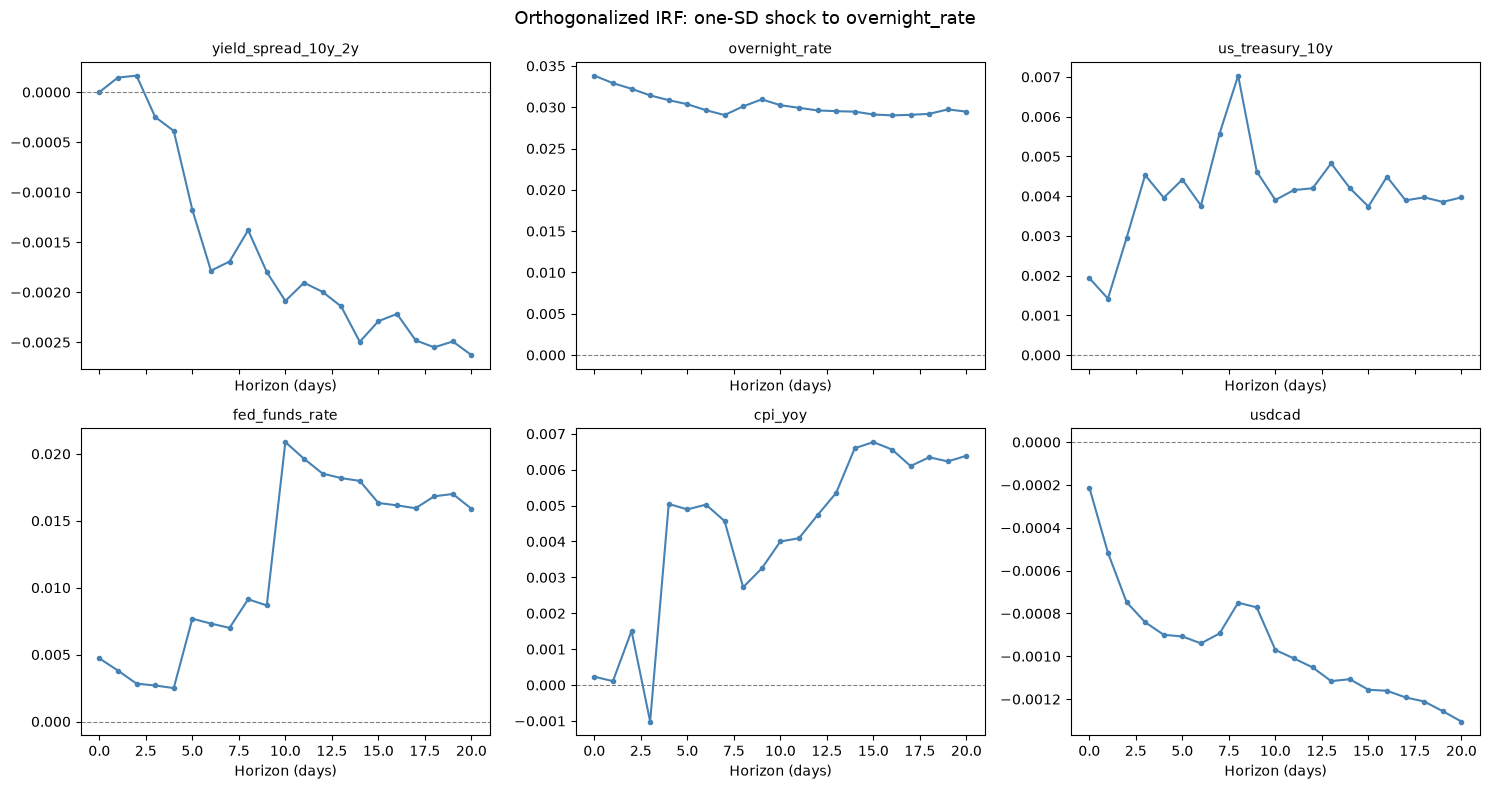

In [4]:
var_names = list(levels.columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, response_var in zip(axes.flat, var_names):
    g = irf_df[irf_df["response_variable"] == response_var].sort_values("horizon_days")
    ax.plot(g["horizon_days"], g["response"], color="steelblue", marker="o", markersize=3)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(response_var, fontsize=10)
    ax.set_xlabel("Horizon (days)")
fig.suptitle(f"Orthogonalized IRF: one-SD shock to {IRF_SHOCK_VAR}", fontsize=13)
fig.tight_layout()
plt.show()

In [5]:
print("Plain-language IRF summary:")
for line in summarize_irf_plain_language(irf_df):
    print(line)

Plain-language IRF summary:
  yield_spread_10y_2y: falls to a peak of -0.0026 at day 20, then remains persistently displaced (day-20 response = -0.0026).
  overnight_rate: rises to a peak of +0.0338 at day 0, then remains persistently displaced (day-20 response = +0.0295).
  us_treasury_10y: rises to a peak of +0.0070 at day 8, then remains persistently displaced (day-20 response = +0.0040).
  fed_funds_rate: rises to a peak of +0.0209 at day 10, then remains persistently displaced (day-20 response = +0.0159).
  cpi_yoy: rises to a peak of +0.0068 at day 15, then remains persistently displaced (day-20 response = +0.0064).
  usdcad: falls to a peak of -0.0013 at day 20, then remains persistently displaced (day-20 response = -0.0013).


## 4. Forecast Error Variance Decomposition (FEVD)

> **Decision Justification — Manual FEVD Computation:** statsmodels' `IRAnalysis.fevd_table()`
> raises `NotImplementedError` for VECM-derived IRFs, and `VARResults.fevd()` isn't exposed on
> `VECMResults`. `compute_fevd()` (`src/irf_fevd_granger.py`) replicates the decomposition manually
> from the cumulative sum of squared orthogonalized IRF coefficients, normalized per horizon — the
> same computation statsmodels performs internally for VAR models. This was verified bit-for-bit
> (max abs diff ≈ 1e-16) against `statsmodels.tsa.vector_ar.var_model.FEVD` on a VAR fit of the
> same data before being applied here.
>
> Reported for the system's two bond yields: `yield_spread_10y_2y` (the target) and
> `us_treasury_10y`.

In [6]:
fevd_df = compute_fevd(irf, levels)
fevd_df.to_csv(PROJECT_ROOT / "outputs" / "fevd_results.csv", index=False)
fevd_df.head()

,horizon_days,response_variable,shock_variable,proportion
0,0,yield_spread_10y_2y,yield_spread_10y_2y,1.0
1,0,yield_spread_10y_2y,overnight_rate,0.0
2,0,yield_spread_10y_2y,us_treasury_10y,0.0
3,0,yield_spread_10y_2y,fed_funds_rate,0.0
4,0,yield_spread_10y_2y,cpi_yoy,0.0


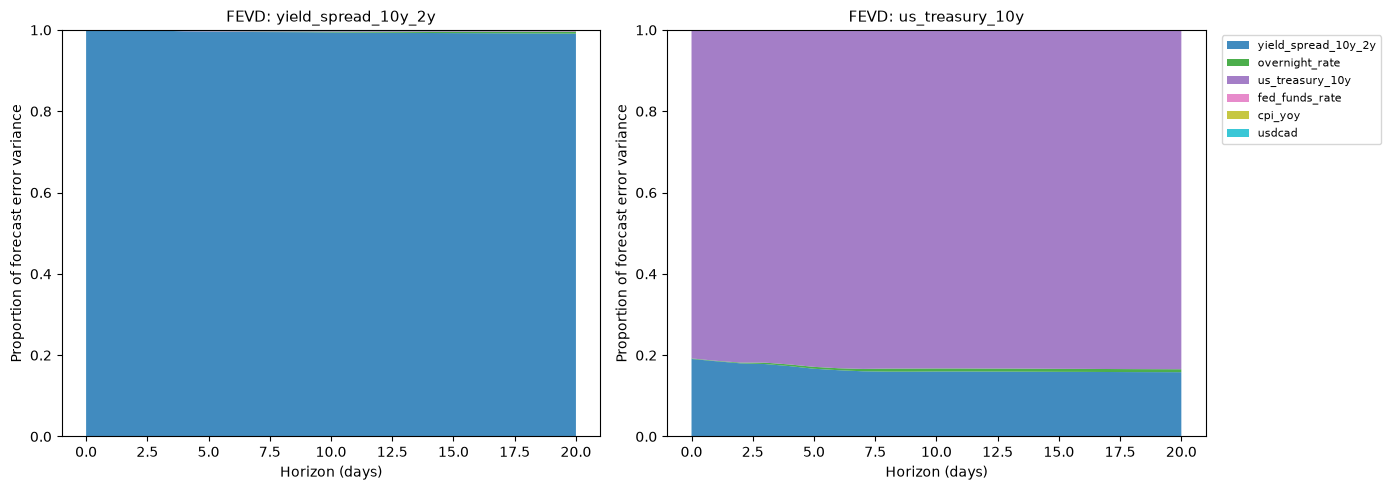

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(var_names)))

for ax, response_var in zip(axes, BOND_YIELDS):
    g = fevd_df[fevd_df["response_variable"] == response_var]
    pivot = g.pivot(index="horizon_days", columns="shock_variable", values="proportion")[var_names]
    ax.stackplot(pivot.index, pivot.T.values, labels=pivot.columns, colors=colors, alpha=0.85)
    ax.set_title(f"FEVD: {response_var}", fontsize=11)
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel("Proportion of forecast error variance")
    ax.set_ylim(0, 1)

axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
fig.tight_layout()
plt.show()

In [8]:
print("Plain-language FEVD summary:")
for h in HORIZONS:
    print(f"Horizon = {h} day(s):")
    for line in summarize_fevd_plain_language(fevd_df, BOND_YIELDS, h):
        print(" " + line)

Plain-language FEVD summary:
Horizon = 1 day(s):
   yield_spread_10y_2y at day 1: yield_spread_10y_2y explains 100.0% of forecast error variance.
   us_treasury_10y at day 1: us_treasury_10y explains 81.4% of forecast error variance.
Horizon = 5 day(s):
   yield_spread_10y_2y at day 5: yield_spread_10y_2y explains 99.6% of forecast error variance.
   us_treasury_10y at day 5: us_treasury_10y explains 82.8% of forecast error variance.
Horizon = 20 day(s):
   yield_spread_10y_2y at day 20: yield_spread_10y_2y explains 99.1% of forecast error variance.
   us_treasury_10y at day 20: us_treasury_10y explains 83.3% of forecast error variance.


## 5. Granger Causality

> **Decision Justification — VECM-Based F-Test, Not a Raw-Levels Granger Test:**
> `VECMResults.test_granger_causality()` runs the F-test on the model's level-VAR representation
> (`var_rep`), which is the valid form for cointegrated I(1) systems — a naive Granger F-test
> applied directly to raw non-stationary levels has non-standard asymptotics (Toda & Phillips,
> 1993) and would be a methodological error here.
>
> **Decision Justification — Test Grid:** Per issue #48's checklist ("policy rate / exchange rate
> → bond yields"), we test each of `overnight_rate`, `fed_funds_rate`, `usdcad` (causing) against
> each of `yield_spread_10y_2y`, `us_treasury_10y` (caused) — 6 tests at α = 0.05.

In [9]:
granger_df = run_granger_causality(vecm_fit)
granger_df.to_csv(PROJECT_ROOT / "outputs" / "granger_causality_results.csv", index=False)
granger_df

,causing,caused,test_statistic,crit_value,df_num,df_denom,p_value,reject_h0,plain_language
0,overnight_rate,yield_spread_10y_2y,1.047903,1.789029,11,25098,0.400276,False,No evidence overnight_rate Granger-causes yiel...
1,fed_funds_rate,yield_spread_10y_2y,1.495726,1.789029,11,25098,0.125212,False,No evidence fed_funds_rate Granger-causes yiel...
2,usdcad,yield_spread_10y_2y,1.275219,1.789029,11,25098,0.231558,False,No evidence usdcad Granger-causes yield_spread...
3,overnight_rate,us_treasury_10y,2.044766,1.789029,11,25098,0.020865,True,overnight_rate Granger-causes us_treasury_10y ...
4,fed_funds_rate,us_treasury_10y,2.063404,1.789029,11,25098,0.019533,True,fed_funds_rate Granger-causes us_treasury_10y ...
5,usdcad,us_treasury_10y,0.881997,1.789029,11,25098,0.557390,False,No evidence usdcad Granger-causes us_treasury_...


In [10]:
print("Plain-language Granger causality summary:")
for _, row in granger_df.iterrows():
    print(f"  {row['plain_language']}")

n_sig = int(granger_df["reject_h0"].sum())
print(f"\n{n_sig}/{len(granger_df)} pairs significant at {SIGNIF:.0%}.")

Plain-language Granger causality summary:
  No evidence overnight_rate Granger-causes yield_spread_10y_2y (p=0.4003 >= 0.05)
  No evidence fed_funds_rate Granger-causes yield_spread_10y_2y (p=0.1252 >= 0.05)
  No evidence usdcad Granger-causes yield_spread_10y_2y (p=0.2316 >= 0.05)
  overnight_rate Granger-causes us_treasury_10y (p=0.0209 < 0.05)
  fed_funds_rate Granger-causes us_treasury_10y (p=0.0195 < 0.05)
  No evidence usdcad Granger-causes us_treasury_10y (p=0.5574 >= 0.05)

2/6 pairs significant at 5%.


## 6. Conclusion

This notebook implemented IRF, FEVD, and Granger causality on the primary 6-variable VECM, as
committed in the project proposal (§5.3) and tracked in issue #48.

**Key findings are documented in the output CSVs:**
- `outputs/irf_overnight_rate_shock.csv` — full IRF trace (every variable's response, h=0..20)
- `outputs/fevd_results.csv` — full FEVD (every response/shock-variable pair, h=0..20)
- `outputs/granger_causality_results.csv` — all 6 policy/FX → bond-yield Granger tests

**Interpretation, in brief:**
- `overnight_rate` and `fed_funds_rate` both Granger-cause `us_treasury_10y` at the 5% level;
  neither does for `yield_spread_10y_2y` in this test, nor does `usdcad` for either yield.
- Under this notebook's Cholesky ordering, `yield_spread_10y_2y`'s FEVD is ~99% explained by its
  own shocks at every horizon tested — consistent with it being ordered first (contemporaneously
  exogenous) rather than evidence the other five variables carry no information about it.

**Known limitation, flagged rather than fixed here:** the Cholesky ordering used throughout
(`FEATURE_SET_6VAR`'s column order, inherited from issue #47) puts the yield spread first. A
policy/macro-first ordering — so that a rate shock can transmit to the spread contemporaneously,
not just with a one-day-plus lag — is a defensible alternative worth testing as a robustness
check, but changing it would also reorder #47's already-reviewed β/α outputs. Left as follow-on
work rather than done unilaterally in this issue.

**Next steps in the dependency chain:**
- Final executive Power BI dashboard (#52) — currently EDA-only; could surface these IRF/FEVD/
  Granger results alongside forecast outputs.